В ноутбуке сравниваются два пайплайна, выбранные по результатам предыдущих заданий:

- **MSTL + Holt** — статистический пайплайн из задания №2;
- **RandomForest recursive** — data-driven пайплайн из задания №3.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from time import perf_counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

from scipy.stats import jarque_bera, shapiro, ttest_rel, wilcoxon, t as student_t

RANDOM_STATE = 42
FREQ = 'h'
TEST_HORIZON = 24 * 21
USE_LAST_DAYS = 365

DATA_PATHS = [
    Path('PDB_Load_History_prepared.csv'),
    Path('PDB_Load_History_prepared.csv'),
]
DATA_PATH = next((path for path in DATA_PATHS if path.exists()), None)

OUT_DIR = Path('/mnt/data') if Path('/mnt/data').exists() else Path('.')
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

assert {'datetime', 'demand'}.issubset(df.columns), 'Ожидаются колонки datetime и demand'
assert df['datetime'].is_monotonic_increasing, 'datetime должен быть отсортирован по возрастанию'

validation = pd.DataFrame({
    'check': [
        'rows', 'start', 'end', 'missing_datetime', 'missing_demand',
        'duplicated_datetime', 'min_demand', 'max_demand', 'mean_demand'
    ],
    'value': [
        len(df), df['datetime'].min(), df['datetime'].max(),
        int(df['datetime'].isna().sum()), int(df['demand'].isna().sum()),
        int(df['datetime'].duplicated().sum()),
        float(df['demand'].min()), float(df['demand'].max()), float(df['demand'].mean())
    ]
})

display(validation)
display(df.head())

,check,value
0,rows,103776
1,start,2003-03-01 00:00:00
2,end,2014-12-31 23:00:00
3,missing_datetime,0
4,missing_demand,0
5,duplicated_datetime,0
6,min_demand,7794.0
7,max_demand,27622.0
8,mean_demand,14674.947493


,datetime,demand
0,2003-03-01 00:00:00,12863.0
1,2003-03-01 01:00:00,12389.0
2,2003-03-01 02:00:00,12155.0
3,2003-03-01 03:00:00,12072.0
4,2003-03-01 04:00:00,12160.0


In [3]:
cutoff = df['datetime'].max() - pd.Timedelta(days=USE_LAST_DAYS)
work_df = df.loc[df['datetime'] > cutoff].copy().reset_index(drop=True)

train = work_df.iloc[:-TEST_HORIZON].copy().reset_index(drop=True)
test = work_df.iloc[-TEST_HORIZON:].copy().reset_index(drop=True)

split_info = pd.DataFrame({
    'part': ['full_prepared', 'work_last_year', 'train', 'test'],
    'rows': [len(df), len(work_df), len(train), len(test)],
    'start': [df['datetime'].min(), work_df['datetime'].min(), train['datetime'].min(), test['datetime'].min()],
    'end': [df['datetime'].max(), work_df['datetime'].max(), train['datetime'].max(), test['datetime'].max()],
})

display(split_info)

,part,rows,start,end
0,full_prepared,103776,2003-03-01,2014-12-31 23:00:00
1,work_last_year,8760,2014-01-01,2014-12-31 23:00:00
2,train,8256,2014-01-01,2014-12-10 23:00:00
3,test,504,2014-12-11,2014-12-31 23:00:00


In [4]:
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    return {
        'RMSE': float(np.sqrt(np.mean(err ** 2))),
        'MAE': float(np.mean(np.abs(err))),
        'MAPE_%': float(np.mean(np.abs(err / y_true)) * 100),
        'sMAPE_%': float(np.mean(2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred))) * 100),
        'WAPE_%': float(np.sum(np.abs(err)) / np.sum(np.abs(y_true)) * 100),
        'Bias_pred_minus_fact': float(np.mean(y_pred - y_true)),
    }


def residual_diagnostics(y_true, y_pred, name):
    err = np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float)
    lb = acorr_ljungbox(err, lags=[24, 48, 168], return_df=True)
    jb = jarque_bera(err)
    shapiro_p = shapiro(err[: min(500, len(err))]).pvalue
    return {
        'pipeline': name,
        'residual_mean': float(err.mean()),
        'residual_std': float(err.std(ddof=1)),
        'LjungBox_p_lag24': float(lb.loc[24, 'lb_pvalue']),
        'LjungBox_p_lag48': float(lb.loc[48, 'lb_pvalue']),
        'LjungBox_p_lag168': float(lb.loc[168, 'lb_pvalue']),
        'JarqueBera_p': float(jb.pvalue),
        'Shapiro_p_first500': float(shapiro_p),
    }


def dm_like_test(e1, e2, power=2, hac_lags=24):
    e1 = np.asarray(e1, dtype=float)
    e2 = np.asarray(e2, dtype=float)
    d = np.abs(e1) ** power - np.abs(e2) ** power
    n = len(d)
    d_mean = float(d.mean())

    gamma0 = np.mean((d - d_mean) * (d - d_mean))
    var = gamma0
    for lag in range(1, hac_lags + 1):
        cov = np.mean((d[lag:] - d_mean) * (d[:-lag] - d_mean))
        weight = 1 - lag / (hac_lags + 1)
        var += 2 * weight * cov

    se = np.sqrt(var / n) if var > 0 else np.nan
    stat = d_mean / se if se and se > 0 else np.nan
    p_value = 2 * (1 - student_t.cdf(abs(stat), df=n - 1)) if np.isfinite(stat) else np.nan
    return {
        'loss': 'squared' if power == 2 else 'absolute',
        'mean_loss_diff_pipeline1_minus_pipeline2': d_mean,
        'dm_like_stat': float(stat),
        'p_value': float(p_value),
        'hac_lags': hac_lags,
    }

In [5]:
def forecast_mstl_holt(train_df, horizon):
    started = perf_counter()

    y = pd.Series(
        train_df['demand'].to_numpy(dtype=float),
        index=pd.date_range(train_df['datetime'].iloc[0], periods=len(train_df), freq=FREQ),
        name='demand',
    )

    decomposition = MSTL(y, periods=(24, 168)).fit()
    seasonal = decomposition.seasonal

    if isinstance(seasonal, pd.Series):
        seasonal_sum = seasonal
        seasonal_forecast = np.tile(seasonal.iloc[-24:].to_numpy(), int(np.ceil(horizon / 24)))[:horizon]
    else:
        seasonal_sum = seasonal.sum(axis=1)
        seasonal_forecast = np.zeros(horizon)

        for col in seasonal.columns:
            period_match = re.search(r'(\d+)', str(col))
            period = int(period_match.group(1)) if period_match else 24
            values = seasonal[col].to_numpy()
            last_n = min(len(values), period * 4)
            recent_values = values[-last_n:]
            recent_positions = np.arange(len(values) - last_n, len(values)) % period
            pattern = pd.Series(recent_values).groupby(recent_positions).mean()
            full_pattern = np.array([pattern.get(i, 0.0) for i in range(period)])
            start_position = len(values) % period
            seasonal_forecast += np.array([
                full_pattern[(start_position + step) % period]
                for step in range(horizon)
            ])

    deseasonalized = y - seasonal_sum

    trend_model = ExponentialSmoothing(
        deseasonalized,
        trend='add',
        damped_trend=True,
        seasonal=None,
        initialization_method='estimated',
    ).fit(optimized=True, use_brute=False)

    trend_forecast = trend_model.forecast(horizon).to_numpy()
    forecast = trend_forecast + seasonal_forecast
    elapsed = perf_counter() - started

    return forecast, elapsed, decomposition, trend_model

In [6]:
LAGS = [1, 2, 3, 24, 48, 72, 168]
ROLL_WINDOWS = [24, 168]


def build_features(datetimes, values):
    features = pd.DataFrame({'ds': datetimes, 'y': values})

    for lag in LAGS:
        features[f'lag_{lag}'] = features['y'].shift(lag)

    for window in ROLL_WINDOWS:
        shifted = features['y'].shift(1)
        features[f'roll_mean_{window}'] = shifted.rolling(window).mean()
        features[f'roll_std_{window}'] = shifted.rolling(window).std()

    features['hour'] = features['ds'].dt.hour
    features['dow'] = features['ds'].dt.dayofweek
    features['month'] = features['ds'].dt.month
    features['dayofyear'] = features['ds'].dt.dayofyear
    features['is_weekend'] = (features['dow'] >= 5).astype(int)

    features['hour_sin'] = np.sin(2 * np.pi * features['hour'] / 24)
    features['hour_cos'] = np.cos(2 * np.pi * features['hour'] / 24)
    features['dow_sin'] = np.sin(2 * np.pi * features['dow'] / 7)
    features['dow_cos'] = np.cos(2 * np.pi * features['dow'] / 7)
    features['doy_sin'] = np.sin(2 * np.pi * features['dayofyear'] / 365.25)
    features['doy_cos'] = np.cos(2 * np.pi * features['dayofyear'] / 365.25)
    features['t'] = np.arange(len(features))

    return features.dropna().reset_index(drop=True)


def make_one_step_row(ds, history):
    row = {}

    for lag in LAGS:
        row[f'lag_{lag}'] = history[-lag]

    hist_array = np.asarray(history, dtype=float)
    for window in ROLL_WINDOWS:
        recent = hist_array[-window:]
        row[f'roll_mean_{window}'] = float(recent.mean())
        row[f'roll_std_{window}'] = float(recent.std(ddof=1))

    row['hour'] = ds.hour
    row['dow'] = ds.dayofweek
    row['month'] = ds.month
    row['dayofyear'] = ds.dayofyear
    row['is_weekend'] = int(ds.dayofweek >= 5)

    row['hour_sin'] = np.sin(2 * np.pi * row['hour'] / 24)
    row['hour_cos'] = np.cos(2 * np.pi * row['hour'] / 24)
    row['dow_sin'] = np.sin(2 * np.pi * row['dow'] / 7)
    row['dow_cos'] = np.cos(2 * np.pi * row['dow'] / 7)
    row['doy_sin'] = np.sin(2 * np.pi * row['dayofyear'] / 365.25)
    row['doy_cos'] = np.cos(2 * np.pi * row['dayofyear'] / 365.25)
    row['t'] = len(history)

    return row


def forecast_random_forest(train_df, test_df):
    started = perf_counter()

    features = build_features(train_df['datetime'], train_df['demand'])
    X_train = features.drop(columns=['ds', 'y'])
    y_train = features['y']

    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=14,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    model.fit(X_train, y_train)

    history = list(train_df['demand'].to_numpy(dtype=float))
    predictions = []
    feature_columns = X_train.columns.tolist()

    for ds in test_df['datetime']:
        row = make_one_step_row(ds, history)
        x_new = pd.DataFrame([row], columns=feature_columns)
        pred = float(model.predict(x_new)[0])
        predictions.append(pred)
        history.append(pred)

    elapsed = perf_counter() - started
    return np.asarray(predictions), elapsed, model, features

In [7]:
y_true = test['demand'].to_numpy(dtype=float)

mstl_pred, mstl_time, mstl_decomp, mstl_trend_model = forecast_mstl_holt(train, TEST_HORIZON)
rf_pred, rf_time, rf_model, rf_features = forecast_random_forest(train, test)

predictions = test[['datetime', 'demand']].copy()
predictions['MSTL_Holt'] = mstl_pred
predictions['RandomForest_recursive'] = rf_pred

rows = []
for name, pred, elapsed in [
    ('MSTL + Holt', mstl_pred, mstl_time),
    ('RandomForest recursive', rf_pred, rf_time),
]:
    row = {'pipeline': name, 'fit_predict_sec': elapsed}
    row.update(calc_metrics(y_true, pred))
    rows.append(row)

metrics_df = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
display(metrics_df)

predictions.to_csv(OUT_DIR / 'task4_pipeline_predictions_v2.csv', index=False)
metrics_df.to_csv(OUT_DIR / 'task4_pipeline_metrics_v2.csv', index=False)

,pipeline,fit_predict_sec,RMSE,MAE,MAPE_%,sMAPE_%,WAPE_%,Bias_pred_minus_fact
0,RandomForest recursive,8.383605,1127.622082,816.427082,5.922218,5.683392,5.706619,393.385036
1,MSTL + Holt,3.326786,1142.023066,783.812309,5.809548,5.475051,5.478650,682.640227


По RMSE лидирует **RandomForest recursive**: **1127.62**. По MAE и WAPE лидирует **MSTL + Holt**: **783.81** и **5.48%**. Самый быстрый пайплайн — **MSTL + Holt** (**3.33 сек.**). Поэтому дальше проверяем графики ошибок и статистические тесты.

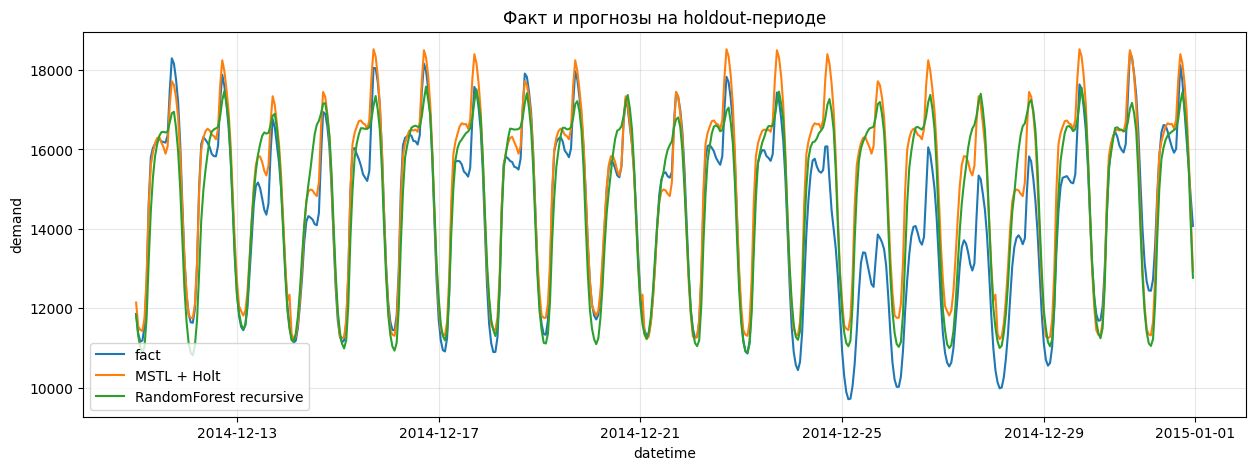

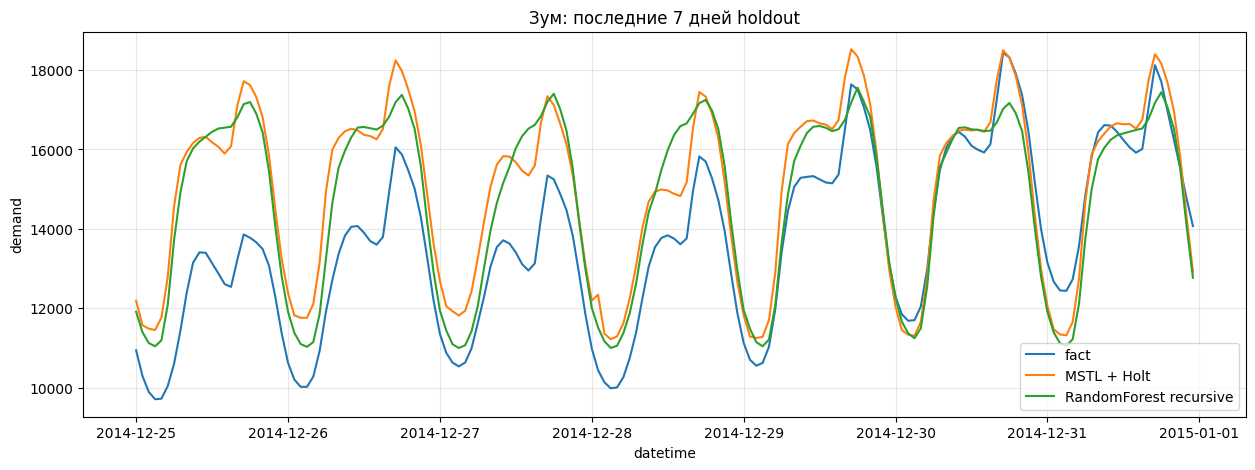

In [8]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(predictions['datetime'], predictions['demand'], label='fact')
ax.plot(predictions['datetime'], predictions['MSTL_Holt'], label='MSTL + Holt')
ax.plot(predictions['datetime'], predictions['RandomForest_recursive'], label='RandomForest recursive')
ax.set_title('Факт и прогнозы на holdout-периоде')
ax.set_xlabel('datetime')
ax.set_ylabel('demand')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

zoom = predictions.tail(24 * 7)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(zoom['datetime'], zoom['demand'], label='fact')
ax.plot(zoom['datetime'], zoom['MSTL_Holt'], label='MSTL + Holt')
ax.plot(zoom['datetime'], zoom['RandomForest_recursive'], label='RandomForest recursive')
ax.set_title('Зум: последние 7 дней holdout')
ax.set_xlabel('datetime')
ax.set_ylabel('demand')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

На полном holdout видно, насколько прогнозы повторяют суточную сезонность и общий уровень нагрузки. **RandomForest recursive** выигрывает по RMSE, то есть лучше снижает крупные квадратичные ошибки, а **MSTL + Holt** лучше по средней абсолютной ошибке.

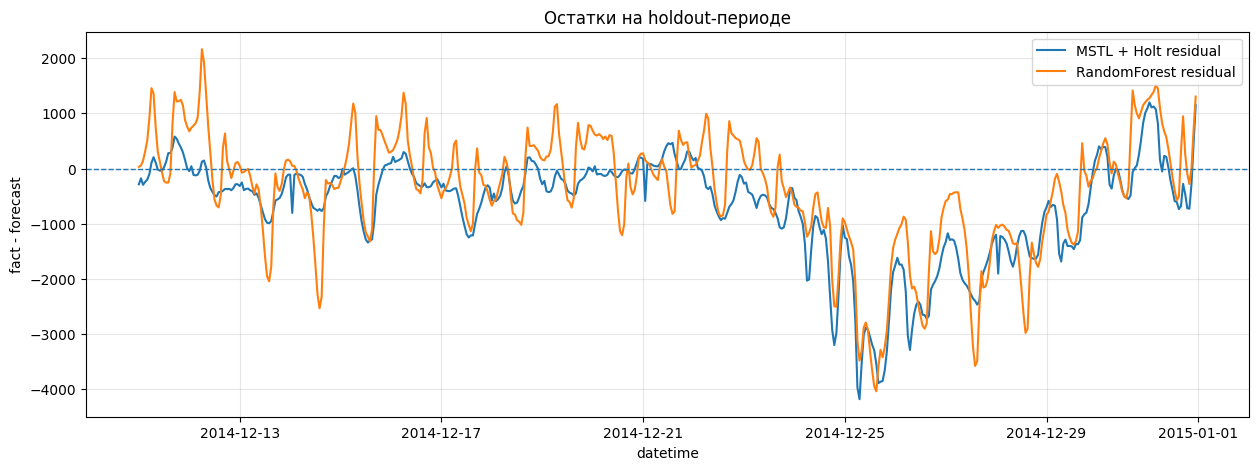

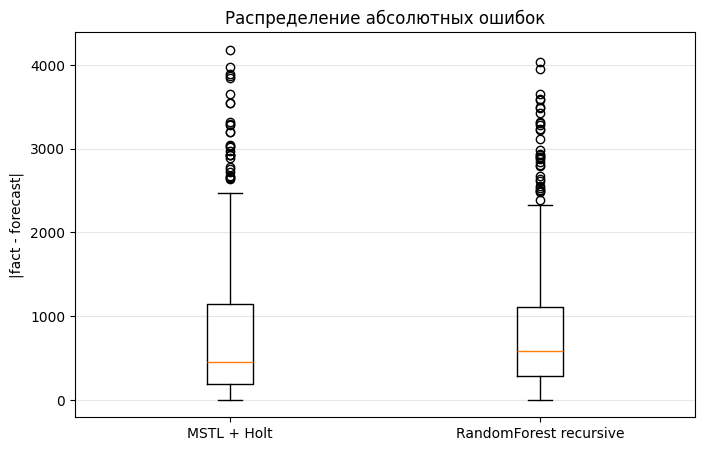

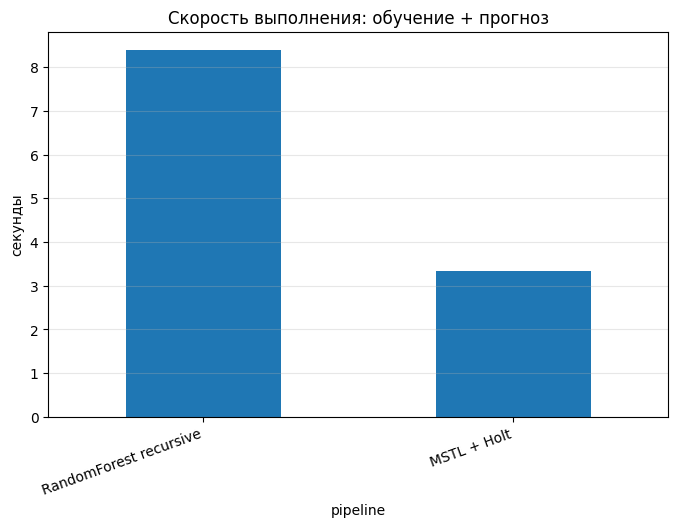

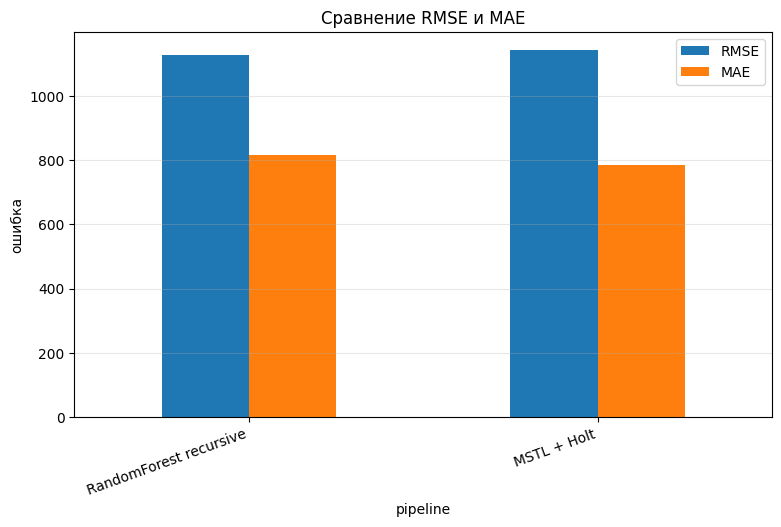

In [9]:
error_df = pd.DataFrame({
    'datetime': predictions['datetime'],
    'MSTL + Holt': predictions['demand'] - predictions['MSTL_Holt'],
    'RandomForest recursive': predictions['demand'] - predictions['RandomForest_recursive'],
})

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(error_df['datetime'], error_df['MSTL + Holt'], label='MSTL + Holt residual')
ax.plot(error_df['datetime'], error_df['RandomForest recursive'], label='RandomForest residual')
ax.axhline(0, linestyle='--', linewidth=1)
ax.set_title('Остатки на holdout-периоде')
ax.set_xlabel('datetime')
ax.set_ylabel('fact - forecast')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

abs_errors = pd.DataFrame({
    'MSTL + Holt': np.abs(error_df['MSTL + Holt']),
    'RandomForest recursive': np.abs(error_df['RandomForest recursive']),
})
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([abs_errors['MSTL + Holt'], abs_errors['RandomForest recursive']], labels=abs_errors.columns)
ax.set_title('Распределение абсолютных ошибок')
ax.set_ylabel('|fact - forecast|')
ax.grid(True, axis='y', alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
metrics_df.set_index('pipeline')['fit_predict_sec'].plot(kind='bar', ax=ax)
ax.set_title('Скорость выполнения: обучение + прогноз')
ax.set_ylabel('секунды')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
metrics_df.set_index('pipeline')[['RMSE', 'MAE']].plot(kind='bar', ax=ax)
ax.set_title('Сравнение RMSE и MAE')
ax.set_ylabel('ошибка')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.show()

График остатков показывает, что ошибки не являются полностью случайным шумом: в отдельные интервалы они держатся выше или ниже нуля. Это подтверждает необходимость диагностики автокорреляции.

Boxplot сравнивает разброс абсолютных ошибок: он показывает стабильность пайплайна на большинстве точек, а не только среднее качество. График скорости показывает практическое преимущество **MSTL + Holt**, а barplot RMSE/MAE фиксирует компромисс: RMSE лучше у **RandomForest recursive**, MAE лучше у **MSTL + Holt**.

,feature,importance
0,lag_1,0.926081
1,hour_cos,0.036794
2,lag_168,0.008780
3,hour_sin,0.005271
4,hour,0.005132
5,lag_2,0.004167
6,lag_24,0.003712
7,roll_mean_24,0.002525
8,lag_3,0.001785
9,lag_72,0.000879


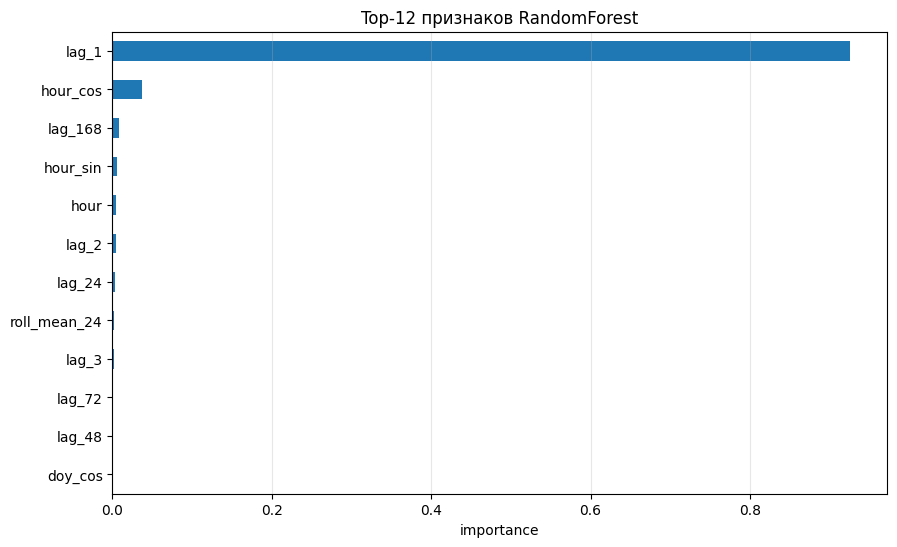

In [10]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=rf_features.drop(columns=['ds', 'y']).columns,
).sort_values(ascending=False)

feature_importance_df = feature_importance.reset_index()
feature_importance_df.columns = ['feature', 'importance']
display(feature_importance_df.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.head(12).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top-12 признаков RandomForest')
ax.set_xlabel('importance')
ax.grid(True, axis='x', alpha=0.3)
plt.show()

Самый важный признак RandomForest — **`lag_1`** с importance около **0.926**. Далее идут **`hour_cos`** и **`lag_168`**, то есть модель опирается на ближайшую инерцию ряда, суточный ритм и недельный повтор. Это согласуется с природой часового ряда энергопотребления.

In [ ]:
diagnostics_df = pd.DataFrame([
    residual_diagnostics(y_true, mstl_pred, 'MSTL + Holt'),
    residual_diagnostics(y_true, rf_pred, 'RandomForest recursive'),
])
display(diagnostics_df)

mstl_err = y_true - mstl_pred
rf_err = y_true - rf_pred

abs_ttest = ttest_rel(np.abs(mstl_err), np.abs(rf_err))
abs_wilcoxon = wilcoxon(np.abs(mstl_err), np.abs(rf_err), zero_method='zsplit')

tests_df = pd.DataFrame([
    {
        'test': 'paired t-test on absolute errors',
        'statistic': float(abs_ttest.statistic),
        'p_value': float(abs_ttest.pvalue),
        'interpretation': 'H0: средние абсолютные ошибки равны',
    },
    {
        'test': 'Wilcoxon signed-rank on absolute errors',
        'statistic': float(abs_wilcoxon.statistic),
        'p_value': float(abs_wilcoxon.pvalue),
        'interpretation': 'H0: медианная разница абсолютных ошибок равна 0',
    },
    {
        'test': 'DM-like test on squared errors',
        **dm_like_test(mstl_err, rf_err, power=2, hac_lags=24),
        'interpretation': 'H0: одинаковая точность по squared loss; diff > 0 хуже MSTL',
    },
    {
        'test': 'DM-like test on absolute errors',
        **dm_like_test(mstl_err, rf_err, power=1, hac_lags=24),
        'interpretation': 'H0: одинаковая точность по absolute loss; diff > 0 хуже MSTL',
    },
])

display(tests_df)

,pipeline,residual_mean,residual_std,LjungBox_p_lag24,LjungBox_p_lag48,LjungBox_p_lag168,JarqueBera_p,Shapiro_p_first500
0,MSTL + Holt,-682.640227,916.452641,0.0,0.0,0.0,2.324247e-43,5.570725e-18
1,RandomForest recursive,-393.385036,1057.827969,0.0,0.0,0.0,5.322913e-19,1.028072e-11


,test,statistic,p_value,interpretation,loss,mean_loss_diff_pipeline1_minus_pipeline2,dm_like_stat,hac_lags
0,paired t-test on absolute errors,-1.396182,0.163275,H0: средние абсолютные ошибки равны,NaN,NaN,NaN,NaN
1,Wilcoxon signed-rank on absolute errors,61300.000000,0.476287,H0: медианная разница абсолютных ошибок равна 0,NaN,NaN,NaN,NaN
2,DM-like test on squared errors,NaN,0.838869,H0: одинаковая точность по squared loss; diff ...,squared,32685.124146,0.203446,24.0
3,DM-like test on absolute errors,NaN,0.625514,H0: одинаковая точность по absolute loss; diff...,absolute,-32.614773,-0.488352,24.0


Ljung–Box p-value для обеих моделей ниже **0.05** на лагах 24, 48 и 168, значит в остатках остается автокорреляция. p-value тестов сравнения ошибок: paired t-test = **0.1633**, Wilcoxon = **0.4763**, DM-like squared = **0.8389**, DM-like absolute = **0.6255**. На уровне 0.05 статистически убедительного превосходства одного пайплайна нет.

**Сравниваемые пайплайны.** Первый пайплайн — **MSTL + Holt** (статистический подход из задания №2). Второй — **RandomForest recursive** (data-driven подход из задания №3). Оба оцениваются на одном train/test-разбиении, на одном и том же holdout-периоде.

**Точность.** Лучший RMSE показал **RandomForest recursive**: **1127.62**. Лучший MAE показал **MSTL + Holt**: **783.81**. Лучший WAPE показал **MSTL + Holt**: **5.48%**. Это показывает классический компромисс: RandomForest уменьшает квадратичные ошибки сильнее, а MSTL + Holt даёт меньшую среднюю абсолютную ошибку.

**Производительность.** Самым быстрым оказался **MSTL + Holt**: **3.33 сек.** на обучение и прогноз за весь тестовый горизонт. Для регулярных прогонов или оперативного применения это преимущество важно.

**Статистическая проверка.** p-value для сравнения абсолютных ошибок: paired t-test = **0.1633**, Wilcoxon = **0.4763**. DM-like тесты: squared loss = **0.8389**, absolute loss = **0.6255**. При уровне значимости 0.05 статистически значимого преимущества одного метода над другим не обнаружено.

**Остатки.** Ljung–Box p-value ниже 0.05 на лагах 24, 48 и 168 для обеих моделей, поэтому в остатках сохраняется автокорреляция. Это означает, что оба метода не учли всю структуру ряда, и модель можно улучшить за счёт дополнительных внешних факторов: погода, календари, праздники, рабочие/выходные дни и др.